# Importing Libraries
___

In [1]:
# Data Handling
import pandas as pd
import numpy as np
# Preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
# Regular Expression
import re
# Machine Learning Proccessors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_score
# Graphing
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Data
___

In [2]:
data = pd.read_csv("/kaggle/input/spam-emails/spam.csv")
data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
data['Category'] = data['Category'].map({'ham': 0, 'spam': 1})
data.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


# Data Preprocessing
___

## Loading NLTK

In [4]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Functions

In [5]:
def clean(text: str) -> str:
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s$€£¥!?]', '', text)
    return text

In [6]:
def preprocess(text: str) -> str:
    text = clean(text)
    text = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in text if word not in stopwords.words('english')]
    return ' '.join(tokens)

## Applying the Functions

In [7]:
data['Message'] = data['Message'].apply(preprocess)

## Saving the Preprocessed Data (Optional)

In [8]:
data.to_csv('preprocessed_data.csv', index=False)

# Creating the Datasets
___

## Data Splitting

In [9]:
train, test = train_test_split(data, test_size=0.2, random_state=42)

## Data Vectorization

In [10]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2))
vectorizer.fit(train['Message'])

TfidfVectorizer(ngram_range=(1, 2))

In [11]:
X_train = vectorizer.transform(train['Message'])
X_test = vectorizer.transform(test['Message'])

In [12]:
y_train = train['Category']
y_test = test['Category']

# Model Training
___

## Logistic Regression

In [13]:
lg = LogisticRegression()
lg.fit(X_train, y_train)

LogisticRegression()

In [14]:
lg_pred = lg.predict(X_test)
lg_accuracy = accuracy_score(y_test, lg_pred)
lg_precision = precision_score(y_test, lg_pred)
lg_recall = recall_score(y_test, lg_pred)
lg_f1 = f1_score(y_test, lg_pred)

print(f"Accuracy Score:    {lg_accuracy:.4f}\n\
Precision Score:   {lg_precision:.4f}\n\
Recall Score:      {lg_recall:.4f}\n\
F1 Score:          {lg_f1:.4f}")

Accuracy Score:    0.9543
Precision Score:   0.9900
Recall Score:      0.6644
F1 Score:          0.7952


## Random Forest Classifier

In [15]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [16]:
rf_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Accuracy Score:    {rf_accuracy:.4f}\n\
Precision Score:   {rf_precision:.4f}\n\
Recall Score:      {rf_recall:.4f}\n\
F1 Score:          {rf_f1:.4f}")

Accuracy Score:    0.9722
Precision Score:   1.0000
Recall Score:      0.7919
F1 Score:          0.8839


## XGBoost

In [17]:
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [18]:
xgb_pred = xgb.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print(f"Accuracy Score:    {xgb_accuracy:.4f}\n\
Precision Score:   {xgb_precision:.4f}\n\
Recall Score:      {xgb_recall:.4f}\n\
F1 Score:          {xgb_f1:.4f}")

Accuracy Score:    0.9650
Precision Score:   0.9911
Recall Score:      0.7450
F1 Score:          0.8506


## SVM

In [19]:
svm = SVC(kernel='linear', C=1.0, probability=True)
svm.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

In [20]:
svm_pred = svm.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print(f"Accuracy Score:    {svm_accuracy:.4f}\n\
Precision Score:   {svm_precision:.4f}\n\
Recall Score:      {svm_recall:.4f}\n\
F1 Score:          {svm_f1:.4f}")

Accuracy Score:    0.9865
Precision Score:   0.9718
Recall Score:      0.9262
F1 Score:          0.9485


# Comparing the Models
___

## Function

In [21]:
def display_score(metric):
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(x='Model', y=f'{metric}', data=scores, palette='viridis')
    plt.ylim(98, 100)
    for p in ax.patches:
        ax.annotate(
            f'{p.get_height():.4f}%',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            fontsize=10,
            color='black',
            xytext=(0, 5),
            textcoords='offset points'
        )
    plt.title(f'{metric}')
    plt.ylabel(f'{metric} (%)', fontsize=14)
    plt.show()

## Scores DataFrame

In [22]:
scores = {
    'Model' : ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM'],
    'Accuracy' : [lg_accuracy, rf_accuracy, xgb_accuracy, svm_accuracy],
    'Precision' : [lg_precision, rf_precision, xgb_precision, svm_precision],
    'Recall' : [lg_recall, rf_recall, xgb_recall, svm_recall],
    'F1-Score' : [lg_f1, rf_f1, xgb_f1, svm_f1]
}
scores = pd.DataFrame(scores)
scores

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.954260,0.990000,0.664430,0.795181
1,Random Forest,0.972197,1.000000,0.791946,0.883895
2,XGBoost,0.965022,0.991071,0.744966,0.850575
3,SVM,0.986547,0.971831,0.926174,0.948454


## Overview

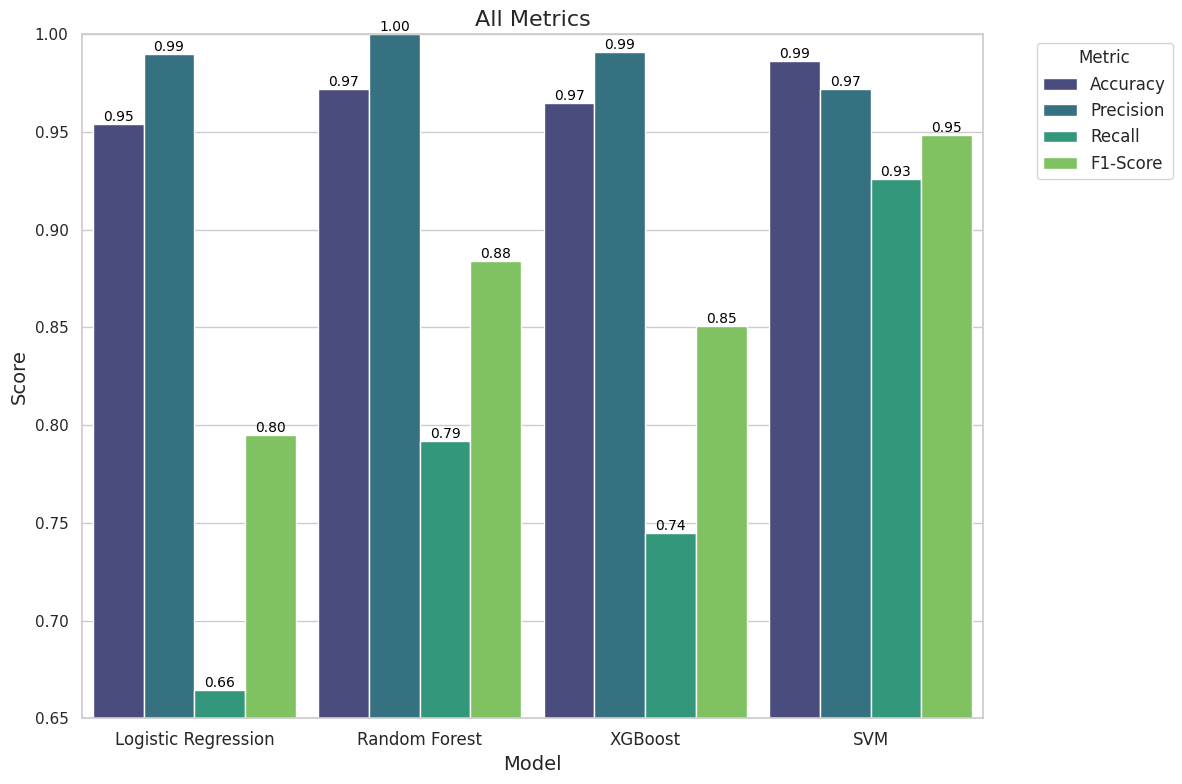

In [23]:
scores_melted = scores.melt(id_vars='Model', var_name='Metric', value_name='Score')

sns.set(style="whitegrid")

plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Model', y='Score', hue='Metric', data=scores_melted, palette='viridis', width=0.9)

plt.ylim(0.65, 1)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        fontsize=10,
        color='black',
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.xticks(fontsize=12)

plt.xlabel('Model', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('All Metrics', fontsize=16)
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.show()

# Validating the Best Model (SVM)
___

## 5-fold Cross Validation

In [24]:
cv_scores = cross_val_score(svm, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy:", cv_scores.mean())

Cross-Validation Accuracy: 0.9712785553592729


# Saving the Best Model (Optional)
___

In [25]:
import joblib

joblib.dump(svm, 'model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

['vectorizer.pkl']